# Problem Statement: Social Media Trolls Identification using ML


## Importing the Libraries

In [1]:
import pandas as pd
import numpy as np
import re 
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

## Data Reading from CSV file

In [2]:
fd = pd.read_csv("data.csv")

## Class Distribution Visualization

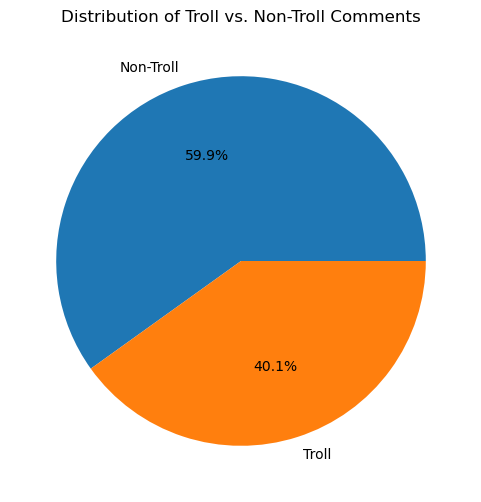

In [3]:
import matplotlib.pyplot as plt

# Count the number of troll and non-troll comments
troll_counts = fd['is_troll'].value_counts()

# Plot the distribution
plt.figure(figsize=(6, 6))
plt.pie(troll_counts, labels=['Non-Troll', 'Troll'], autopct='%1.1f%%')
plt.title('Distribution of Troll vs. Non-Troll Comments')
plt.show()

## Data Preprocessing

In [4]:
corpus = []
# print(len(fd['body']))
for i in range(0, len(fd['body'])):
    review = re.sub('[^a-zA-Z]', ' ', fd['body'][i])
    review= review.lower()
    review = review.split()
    ps = PorterStemmer()
    all_stopwords = stopwords.words('english')
    all_stopwords.remove('not')
    review = [ps.stem(word) for word in review if not word in set(all_stopwords)]
    review =' '.join(review)
    corpus.append(review)

## Checking corpus

In [5]:
print(corpus[: 5])
print(len(corpus))

['hard look train tactic sent train', 'deserv hate', 'guess mean say see color', 'never late never cruel brutal still probabl get away', 'http petit whitehous gov petit petit creat nationwid elect publicli review polic oversight agenc']
16695


## Feature Defining (Independent and Dependent)

In [6]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features = 3000)
X = cv.fit_transform(corpus).toarray()
y = fd.iloc[:, 0].values

In [7]:
print(X.shape)
print(X[0])

(16695, 3000)
[0 0 0 ... 0 0 0]


## Checking Shape of features

In [8]:
X.shape
y.shape
print(X.shape)
# print(y[: 5])

(16695, 3000)


## Word Cloud Visualization

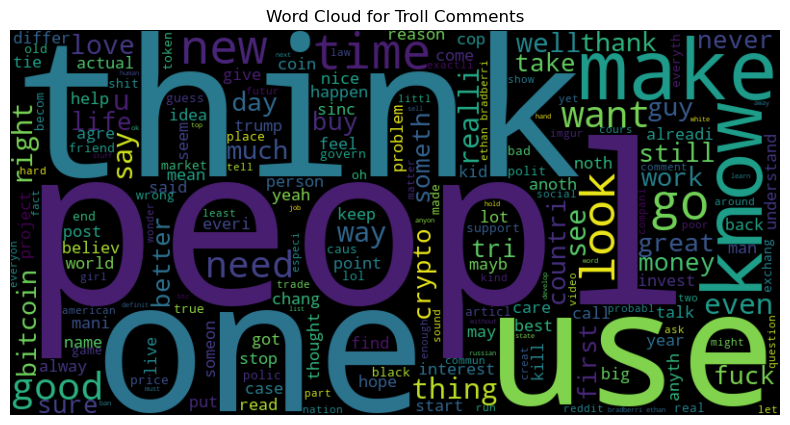

In [9]:
# Import the necessary libraries
from wordcloud import WordCloud

# Create a WordCloud for troll comments
troll_corpus = " ".join([corpus[i] for i in range(len(corpus)) if y[i] == 1])

# Generate the WordCloud
wordcloud = WordCloud(width=800, height=400).generate(troll_corpus)

# Plot the WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud for Troll Comments")
plt.show()

## Splitting the training and test data sets

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

## Trainin model using Artificial Neural Network

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

model = Sequential(
    [               
        tf.keras.Input(shape=(3000,)),
        Dense(units=25, activation="relu", name='layer1'),
        Dense(units=15, activation="relu", name='layer2'),
        Dense(units=10, activation="linear", name='layer3'),
    ], name = "my_model" 
)

model.compile(loss= SparseCategoricalCrossentropy(from_logits = True), metrics = ["accuracy"], optimizer= Adam())

y_train = y_train.reshape(-1)
history =  model.fit(X_train, y_train, epochs = 15)

Epoch 1/15
418/418 [==============================] - 2s 2ms/step - loss: 0.7802 - accuracy: 0.7472
Epoch 2/15
418/418 [==============================] - 1s 2ms/step - loss: 0.1805 - accuracy: 0.9373
Epoch 3/15
418/418 [==============================] - 1s 2ms/step - loss: 0.1083 - accuracy: 0.9628
Epoch 4/15
418/418 [==============================] - 1s 2ms/step - loss: 0.0796 - accuracy: 0.9716
Epoch 5/15
418/418 [==============================] - 1s 2ms/step - loss: 0.0627 - accuracy: 0.9778
Epoch 6/15
418/418 [==============================] - 1s 2ms/step - loss: 0.0529 - accuracy: 0.9811
Epoch 7/15
418/418 [==============================] - 1s 2ms/step - loss: 0.0464 - accuracy: 0.9834
Epoch 8/15
418/418 [==============================] - 1s 2ms/step - loss: 0.0431 - accuracy: 0.9850
Epoch 9/15
418/418 [==============================] - 1s 2ms/step - loss: 0.0387 - accuracy: 0.9867
Epoch 10/15
418/418 [==============================] - 1s 2ms/step - loss: 0.0357 - accuracy: 0.9869

In [12]:
y_pred = model(X_test)
print(y_pred[0])
y_label = np.argmax(y_pred, axis=1)
print(y_label[0])

tf.Tensor(
[ 23.905943  -9.421978 -14.958626 -12.478202 -11.912412  -8.46705
 -13.59421  -18.94966   -9.031911 -17.204985], shape=(10,), dtype=float32)
0


Text(0, 0.5, 'loss')

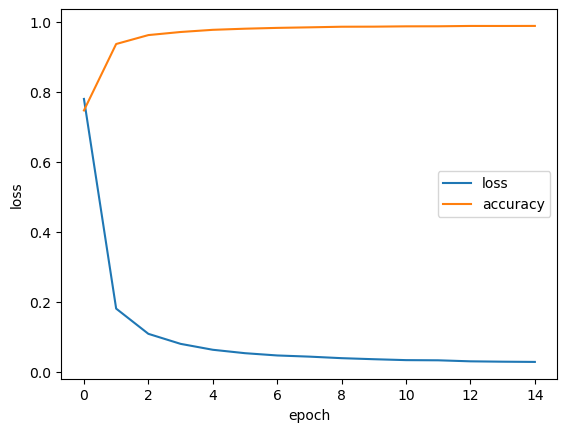

In [13]:
pd.DataFrame(history.history).plot()
plt.xlabel("epoch")
plt.ylabel("loss")

418/418 [==============================] - 1s 1ms/step


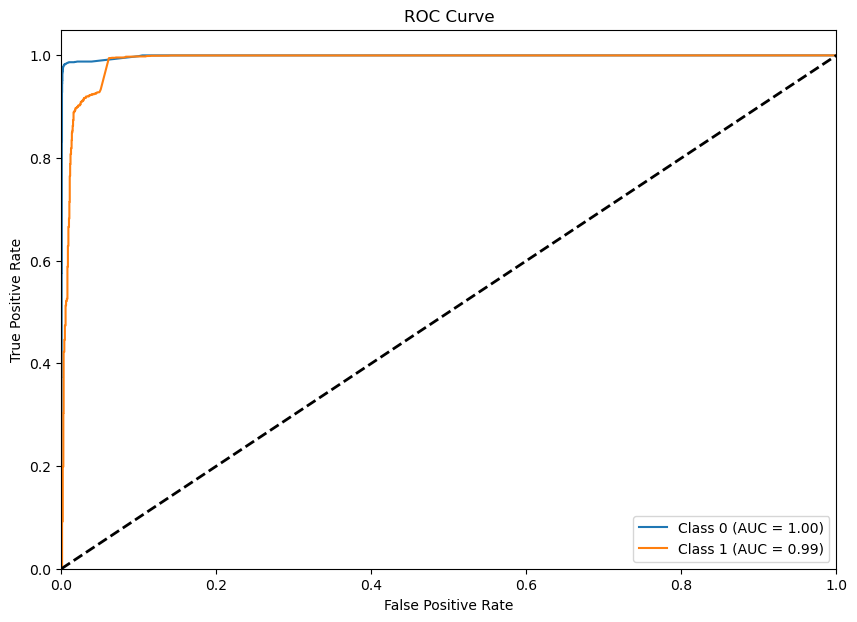

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Make predictions using your model
y_pred = model.predict(X_train)

# Step 2: Calculate the ROC curve for each class
n_classes = y_train.max() + 1  # Number of classes
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    # Compute ROC curve and ROC area for each class
    fpr[i], tpr[i], _ = roc_curve((y_train == i).astype(int), y_pred[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 3: Plot the ROC curves
plt.figure(figsize=(10, 7))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)  # Diagonal line for reference
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [15]:
def widgvis(fig):
    fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

## Predicting the result 

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy_score(y_test, y_label)

0.9550763701707098

# Model Evaluation Visualization:

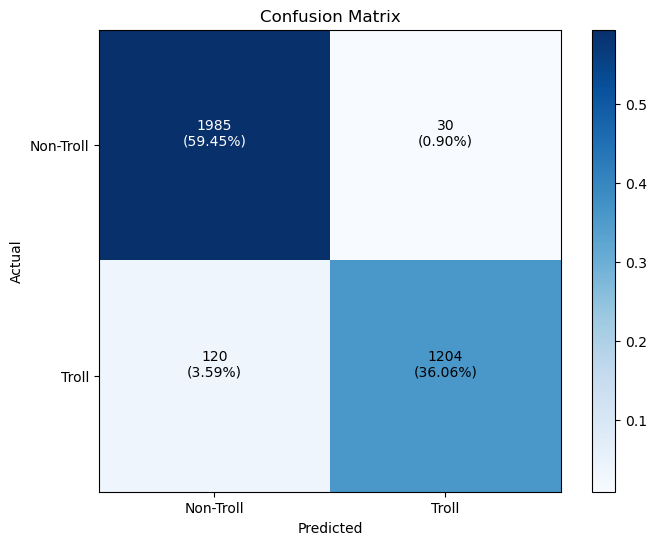

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_label)

# Calculate percentages
total = cm.sum()
cm_percent = cm / total

# Plot the confusion matrix with percentages
plt.figure(figsize=(8, 6))
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)

# Annotate the cells with percentages
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]}\n({cm_percent[i, j]*100:.2f}%)",
                 horizontalalignment="center",
                 color="white" if cm_percent[i, j] > 0.5 else "black")

plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Non-Troll", "Troll"])
plt.yticks([0, 1], ["Non-Troll", "Troll"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Trianing model using Support Vector Machine

In [18]:
from sklearn.svm import SVC  # Import the Support Vector Classifier
classifier_svm = SVC(kernel='linear', C=1.0)
classifier_svm.fit(X_train, y_train)

SVC(kernel='linear')

## Predicting the result using Support Vector Machine

In [19]:
y_pred1 = classifier_svm.predict(X_test)
accuracy_score(y_test, y_pred1)

0.9418987720874513

# Model Evaluation Visualization

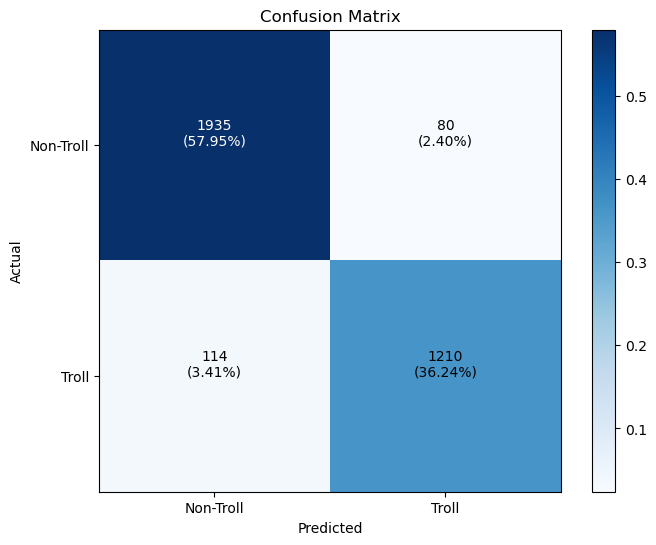

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred1)

# Calculate percentages
total = cm.sum()
cm_percent = cm / total

# Plot the confusion matrix with percentages
plt.figure(figsize=(8, 6))
plt.imshow(cm_percent, interpolation='nearest', cmap=plt.cm.Blues)

# Annotate the cells with percentages
for i in range(2):
    for j in range(2):
        plt.text(j, i, f"{cm[i, j]}\n({cm_percent[i, j]*100:.2f}%)",
                 horizontalalignment="center",
                 color="white" if cm_percent[i, j] > 0.5 else "black")

plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["Non-Troll", "Troll"])
plt.yticks([0, 1], ["Non-Troll", "Troll"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()